# Google TabFM — Zero to Mastery: Classification

**A complete, hands-on tutorial on Google Research's TabFM (Tabular Foundation Model)**, applied
end-to-end to a real binary classification problem: predicting whether a person's income
exceeds $50K/year from US Census data.

This notebook does not assume you already know what a tabular foundation model is. It builds
the idea up from first principles, then walks through every step of a real pipeline: environment
setup, data download, preprocessing, zero-shot inference with TabFM, calibration, interpretation,
and a head-to-head comparison against tuned classical baselines (`LogisticRegression`, `XGBoost`).

**Dataset:** UCI Adult / Census Income (48,842 rows), downloaded live from OpenML inside this
notebook — no bundled files.

**Hardware:** Runs on CPU. TabFM's compute cost is dominated by how many rows you show it as
context, not by whether you have a GPU — we measured this ourselves (Section 3) and it changes
how you should think about "scaling up."

**Estimated runtime:** ~25–35 minutes on a modern laptop CPU, most of it inside the two TabFM
inference cells in Sections 9 and 10. The first call to the model also pays a one-off multi-GB
weight download (cached afterwards).

**License note:** TabFM's *code* is Apache-2.0, but the *pretrained weights* are released under a
**non-commercial** license (see Section 2). This notebook is for learning and evaluation.

---


## 1. What Is a Tabular Foundation Model?

For a decade, "foundation model" has meant something specific in text and vision: pretrain one
very large network on a huge, generic corpus, then reuse it on new tasks with little or no
task-specific training — zero-shot or few-shot. GPT-style language models and CLIP-style vision
models are the canonical examples.

Tabular data resisted this playbook for a structural reason: **a spreadsheet has no shared
vocabulary.** The column called `age` in one dataset and `hours-per-week` in another don't share
a token embedding the way the word "dog" means the same thing in every English sentence. Column
*semantics*, *count*, *order*, and *scale* are different in every dataset. A model pretrained on
one company's customer table has no obvious way to transfer to another company's completely
different schema. This is why, for years, the standard advice for tabular problems stayed
"just use a well-tuned gradient-boosted tree" (XGBoost, LightGBM, CatBoost) — trained fresh, from
scratch, on every new dataset.

**In-context learning (ICL)** is the trick that got around this. Instead of trying to build a
shared vocabulary across arbitrary schemas, an ICL tabular model treats the *entire training set*
as a prompt: it reads your labeled training rows as context, then predicts the label for new rows
*in a single forward pass* — no gradient updates, no per-dataset training. The model is pretrained
once, on a huge number of *synthetic* tables designed so it learns the general skill of "infer
patterns from a table of examples," and that general skill transfers to any new table you hand it
at inference time — since every dataset ships its own "training set" as its own bespoke context.

This lineage started with **TabPFN** (Prior Labs / Hollmann et al.), which introduced
Prior-Fitted Networks for small tabular tasks, and continued with **TabICL**, which scaled ICL to
larger tables by compressing rows before running the expensive in-context attention step. Google's
**TabFM**, the subject of this notebook, combines both ideas into one model.

**Key definitions for this notebook:**

| Term | Meaning here |
|---|---|
| **Zero-shot inference** | Making predictions on a new dataset without any dataset-specific training or hyperparameter search. |
| **In-context learning (ICL)** | The model reads labeled examples as *context* at inference time, rather than updating its weights on them. |
| **Foundation model** | One set of pretrained weights, reused across many downstream tasks/datasets without retraining. |
| **"Fitting" a TabFM classifier** | Does *not* mean gradient descent on your data. It means preparing the encoders and the ensemble configuration — the actual "learning" happens inside the frozen model at prediction time. |


## 2. Google TabFM: Architecture, Training, and Where It Fits

TabFM was announced by **Google Research** (not Google DeepMind, not a Cloud product team) via a
[research blog post](https://research.google/blog/introducing-tabfm-a-zero-shot-foundation-model-for-tabular-data/),
an open [GitHub repo](https://github.com/google-research/tabfm), and Hugging Face model cards. It is
explicitly positioned as the tabular sibling to Google's own time-series foundation model,
**TimesFM** — same "one pretrained model, many downstream datasets" idea, applied to tables instead
of sequences.

**Architecture** — a three-stage hybrid of TabPFN's and TabICL's ideas:

1. **Column attention** (TabPFN/Set-Transformer style): each cell is embedded with Fourier
   features, then columns attend to each other via induced self-attention.
2. **Row compression** (TabICL style): CLS tokens with Rotary Position Embedding compress every
   full row into one dense vector — this is what keeps the expensive next stage tractable on large
   tables.
3. **In-context Transformer**: a 24-block causal transformer runs over the sequence of compressed
   row vectors, treating training rows as context and test rows as the query.

| Hyperparameter | Value |
|---|---|
| Embedding dim | 256 |
| Column-attention blocks | 3 (4 heads, 256 induced points) |
| Row-attention blocks | 3 (8 heads, 8 CLS tokens) |
| ICL transformer blocks | 24 (8 heads) |
| Activation | SwiGLU |
| Max classes | **10 (hard limit)** |
| Optimized table width | up to ~500 features |

**Training data:** entirely **synthetic** — hundreds of millions of tables generated from
structural causal models (SCMs). Google chose this deliberately: real tabular data at this scale
is scarce, proprietary, and privacy-encumbered, so a synthetic prior sidesteps all three problems.
No total parameter count or compute budget has been publicly disclosed.

**License split — read this before you build anything on top of it:** the source code is
Apache-2.0, but the pretrained *weights* ship under a bespoke **"TabFM Non-Commercial License
v1.0."** Commercial use requires a separate license from Google. There is also, as of this
writing, **no arXiv paper or technical report** — the entire public record is the blog post, the
GitHub README, and the Hugging Face model cards.

**Evaluation:** Google benchmarked TabFM on **TabArena** (51 datasets: 38 classification, 13
regression) and reports that it beats heavily-tuned gradient-boosted-tree baselines zero-shot. This
is Google's own self-reported result; at the time of writing there is no independent, peer-reviewed
reproduction of that exact claim, so we build our own honest, from-scratch comparison against
`LogisticRegression` and `XGBoost` later in this notebook rather than taking the headline claim on
faith.


## 3. Environment Setup

We use **[uv](https://docs.astral.sh/uv/)** to manage this environment: `uv venv --python 3.13.13`
created the virtual environment this kernel runs in, and the cell below uses `uv pip install`
(targeted at this kernel's own interpreter) to install every dependency this notebook needs. It is
safe to re-run.

**A real gotcha we hit building this notebook, worth knowing about:** the version of `tabfm`
currently on PyPI (`1.0.0`) ships a loader that looks for a file named `pytorch_model.bin`, but the
actual Hugging Face weights are stored as `model.safetensors` — so `pip install tabfm[pytorch]`
followed by the documented Quick Start code raises a `FileNotFoundError` out of the box. This
matches a bug already reported on the project's GitHub issue tracker just days after launch. The
fix: install directly from the GitHub `main` branch, which uses the corrected Hugging Face loading
path. We also need the `safetensors` package explicitly — `huggingface_hub`'s safetensors loader
imports it lazily and fails with an unhelpful `NameError` if it's missing.


In [1]:
import sys

# Installs the exact stack this notebook needs via uv, targeting this kernel's own
# interpreter. Installing tabfm from GitHub main (not PyPI) sidesteps the broken
# pytorch_model.bin loader in the 1.0.0 PyPI release — see the markdown above.
!uv pip install --python {sys.executable} -q \
    "tabfm[pytorch] @ git+https://github.com/google-research/tabfm.git" \
    safetensors scikit-learn pandas numpy matplotlib seaborn xgboost


In [2]:
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, log_loss, brier_score_loss,
    confusion_matrix, classification_report,
)
from sklearn.calibration import calibration_curve

sns.set_theme(style="whitegrid")
print(f"torch {torch.__version__} | cuda available: {torch.cuda.is_available()}")


torch 2.12.1+cu130 | cuda available: True


### A note on device selection

TabFM's own benchmarks report ~20–25 minutes of GPU compilation/download overhead on the *first*
call and heavy per-fold GPU cost thereafter. In practice, GPUs are also often shared with other
workloads (other notebooks, local LLM servers, etc.), so grabbing the GPU unconditionally is
antisocial. The helper below only asks for CUDA if there is *comfortably* enough free memory —
otherwise it falls back to CPU. We also measured, empirically, that on CPU the model's default
`bfloat16` compute dtype is roughly **4× slower** than plain `float32` (bf16 matmul is only fast
with hardware support most CPUs lack) — so we explicitly request `float32` when running on CPU.


In [3]:
def pick_device(min_free_gb=6.0):
    """Use the GPU only if it looks genuinely free; it may be shared with other processes."""
    if not torch.cuda.is_available():
        return "cpu"
    free_bytes, _ = torch.cuda.mem_get_info()
    free_gb = free_bytes / 1e9
    print(f"GPU free memory: {free_gb:.2f} GB")
    return "cuda" if free_gb >= min_free_gb else "cpu"

DEVICE = pick_device()
COMPUTE_DTYPE = torch.float32  # empirically ~4x faster than the bf16 default on CPU
print("Selected device:", DEVICE, "| dtype:", COMPUTE_DTYPE)


GPU free memory: 8.04 GB
Selected device: cuda | dtype: torch.float32


## 4. Loading TabFM

`tabfm_v1_0_0.load()` downloads the pretrained weights from Hugging Face on first use (they are
**not gated** — no login/token required) and caches them locally afterwards. We wrap the call in a
GPU-OOM fallback, consistent with the shared-hardware caution above.


In [4]:
from tabfm import TabFMClassifier, tabfm_v1_0_0_pytorch as tabfm_v1_0_0

t0 = time.time()
try:
    tabfm_model = tabfm_v1_0_0.load(model_type="classification", device=DEVICE, dtype=COMPUTE_DTYPE)
except torch.cuda.OutOfMemoryError:
    print("GPU out of memory — falling back to CPU.")
    DEVICE = "cpu"
    tabfm_model = tabfm_v1_0_0.load(model_type="classification", device=DEVICE, dtype=COMPUTE_DTYPE)
print(f"Loaded TabFM classification weights on {DEVICE} in {time.time() - t0:.1f}s")


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights from local directory


Loaded TabFM classification weights on cuda in 9.0s


## 5. Dataset: UCI Adult / Census Income

The **Adult** dataset (a.k.a. Census Income) is one of the oldest and most widely used tabular
benchmarks: 48,842 rows describing US adults from the 1994 Census, with the task of predicting
whether each person's income exceeds $50K/year. It has a healthy mix of numeric columns (`age`,
`hours-per-week`, `capital-gain`, ...) and categorical columns (`workclass`, `education`,
`occupation`, ...), real missing values, and real class imbalance — everything a "production-grade"
tabular classification problem actually looks like. It is also, concretely, the exact dataset used
in one of the only independent third-party benchmarks of TabFM found during our research, so
results here are directly comparable to published numbers elsewhere.

The dataset also carries the protected attributes `sex` and `race`, which we'll return to in
Section 13 to audit subgroup performance — TabFM's own model card explicitly states that its
"performance on specific real-world domains, minority groups, or edge distributions is not fully
characterised," so let's check that ourselves rather than take it on faith.

We fetch it live from OpenML (not a bundled file) via `scikit-learn`.


In [5]:
from sklearn.datasets import fetch_openml

t0 = time.time()
adult = fetch_openml(name="adult", version=2, as_frame=True, data_home=".cache_data", parser="auto").frame
print(f"Downloaded Adult Income dataset: {adult.shape[0]:,} rows x {adult.shape[1]} columns in {time.time() - t0:.1f}s")
adult.head()


Downloaded Adult Income dataset: 48,842 rows x 15 columns in 0.1s


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## 6. Exploratory Data Analysis

Before touching any model, let's look at what we actually have: missingness, class balance, and a
couple of feature distributions split by the target.


In [6]:
missing = adult.isna().sum()
print("Missing values per column:")
print(missing[missing > 0])

print("\nTarget distribution:")
print(adult["class"].value_counts())
print((adult["class"].value_counts(normalize=True) * 100).round(1).astype(str) + "%")


Missing values per column:
workclass         2799
occupation        2809
native-country     857
dtype: int64

Target distribution:
class
<=50K    37155
>50K     11687
Name: count, dtype: int64
class
<=50K    76.1%
>50K     23.9%
Name: proportion, dtype: str


`workclass`, `occupation`, and `native-country` have real missing values (not the placeholder `"?"`
strings from the original UCI release — OpenML's version 2 has already cleaned those to proper
`NaN`). TabFM's own preprocessing pipeline (`TransformToNumerical`) imputes numeric columns with
the median/mean and encodes missing categoricals as an explicit "unknown" bucket internally, so we
don't need to hand-roll imputation before handing data to TabFM — but our classical baselines in
Section 8 will need their own imputation, since scikit-learn estimators don't do this for you.

The target is imbalanced: roughly 3-to-1 in favor of `<=50K`. Keep that in mind when reading raw
accuracy — a model that always predicts `<=50K` would already score ~76%.


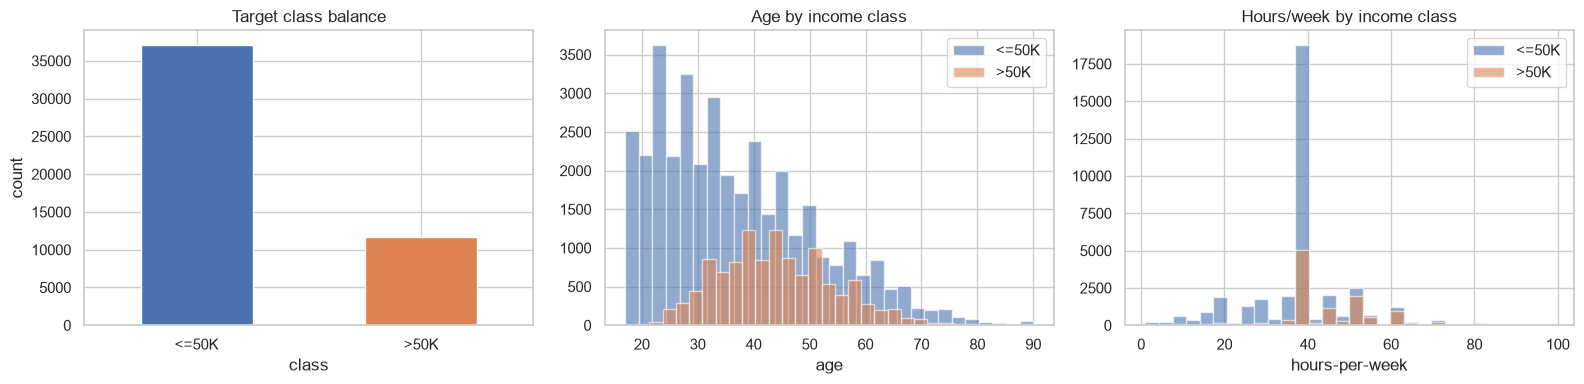

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette = {"<=50K": "#4C72B0", ">50K": "#DD8452"}

adult["class"].value_counts().reindex(["<=50K", ">50K"]).plot(
    kind="bar", ax=axes[0], color=[palette["<=50K"], palette[">50K"]]
)
axes[0].set_title("Target class balance")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

for cls in ["<=50K", ">50K"]:
    axes[1].hist(adult.loc[adult["class"] == cls, "age"], bins=30, alpha=0.6, label=cls, color=palette[cls])
axes[1].set_title("Age by income class")
axes[1].set_xlabel("age")
axes[1].legend()

for cls in ["<=50K", ">50K"]:
    axes[2].hist(adult.loc[adult["class"] == cls, "hours-per-week"], bins=30, alpha=0.6, label=cls, color=palette[cls])
axes[2].set_title("Hours/week by income class")
axes[2].set_xlabel("hours-per-week")
axes[2].legend()

plt.tight_layout()
plt.show()


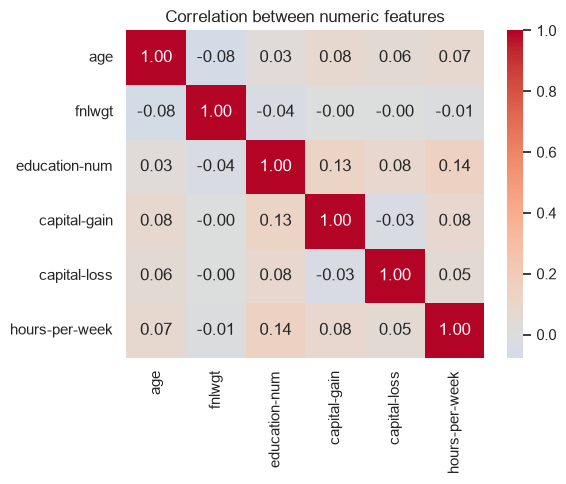

In [8]:
numeric_cols = adult.select_dtypes(include="number").columns
corr = adult[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()


## 7. Train/Test Split and the In-Context "Training" Set

Here's the part that's genuinely different from a classical pipeline. For `LogisticRegression` or
`XGBoost`, "fitting" means running an optimizer over the *entire* training set. For TabFM,
`.fit()` only prepares data encoders — the real "learning" happens inside the frozen, pretrained
model *at prediction time*, when it reads your training rows as context alongside the rows you
want predictions for.

That has a direct, practical consequence: **every row you pass as context is attended over at
every prediction call**, and TabFM's own model card states plainly that "memory usage scales with
the number of training rows" and that it's "optimised for tables up to 500 features" — there's no
free lunch where a bigger context is always better with no cost. We measured this ourselves while
building this notebook: on CPU, going from ~1,000 to ~2,500 total context+query rows increased
per-ensemble-member latency from ~12s to ~32s — worse than linear.

So instead of showing TabFM the full ~39,000-row training pool, we **deliberately subsample a
fixed-size context** (`N_CONTEXT`) and a fixed-size evaluation set (`N_EVAL`), stratified to
preserve the class balance. This is not cutting a corner to save time in this tutorial — it is
*exactly* the tradeoff you'd navigate in any real deployment of an in-context tabular model: how
much context can you afford to pay for, in latency and memory, per prediction? Our classical
baselines, by contrast, train on the *entire* training pool, since that costs them nothing extra —
this makes the comparison in Section 9–10 an honest "TabFM with a bounded context" vs. "GBM with
all the data it wants."


In [9]:
FEATURES = [c for c in adult.columns if c != "class"]
X = adult[FEATURES]
y = adult["class"].astype(str)

X_train_pool, X_test_pool, y_train_pool, y_test_pool = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train pool: {len(X_train_pool):,} rows | Test pool: {len(X_test_pool):,} rows")


Train pool: 39,073 rows | Test pool: 9,769 rows


In [10]:
N_CONTEXT = 2000   # rows shown to TabFM as in-context "training" examples
N_EVAL = 1000       # rows every model (TabFM included) is scored on


def stratified_subsample(X, y, n, seed=42):
    idx, _ = train_test_split(np.arange(len(X)), train_size=n, stratify=y, random_state=seed)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


X_context, y_context = stratified_subsample(X_train_pool, y_train_pool, N_CONTEXT)
X_eval, y_eval = stratified_subsample(X_test_pool, y_test_pool, N_EVAL)

print("Context class balance:")
print(y_context.value_counts(normalize=True).round(3))
print("\nEval class balance:")
print(y_eval.value_counts(normalize=True).round(3))


Context class balance:
class
<=50K    0.76
>50K     0.24
Name: proportion, dtype: float64

Eval class balance:
class
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64


## 8. Baseline Models

We compare TabFM against two classical baselines, both trained on the **full** ~39,000-row training
pool (they have no context-size penalty, so there's no reason to hobble them):

- **`LogisticRegression`** — a simple, well-understood linear baseline, with proper one-hot
  encoding and standardization via a `ColumnTransformer`.
- **`XGBoost`** — the "well-tuned gradient-boosted tree" that Google's own TabArena claims TabFM
  beats. We use native categorical support (`enable_categorical=True`) and reasonable defaults
  rather than a full hyperparameter search — a real production comparison would tune this further,
  but a lightly-tuned XGBoost is already a strong, realistic bar to clear.

Both are scored on the exact same 1,000-row `X_eval` we just carved out, so every model in this
notebook is judged on identical held-out data.


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb

cat_cols = X.select_dtypes(include="category").columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()

logreg_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num_cols),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
    ])),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

t0 = time.time()
logreg_pipe.fit(X_train_pool, y_train_pool)
print(f"LogisticRegression fit on {len(X_train_pool):,} rows in {time.time() - t0:.1f}s")

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    tree_method="hist", enable_categorical=True, random_state=42,
)
y_train_pool_bin = (y_train_pool == ">50K").astype(int)
y_eval_bin = (y_eval == ">50K").astype(int)

t0 = time.time()
xgb_clf.fit(X_train_pool, y_train_pool_bin)
print(f"XGBoost fit on {len(X_train_pool):,} rows in {time.time() - t0:.1f}s")


LogisticRegression fit on 39,073 rows in 0.2s


XGBoost fit on 39,073 rows in 0.4s


In [12]:
logreg_proba = logreg_pipe.predict_proba(X_eval)[:, list(logreg_pipe.classes_).index(">50K")]
xgb_proba = xgb_clf.predict_proba(X_eval)[:, 1]

results = {}


def score(name, y_true_bin, proba, pred=None):
    if pred is None:
        pred = (proba >= 0.5).astype(int)
    results[name] = {
        "accuracy": accuracy_score(y_true_bin, pred),
        "roc_auc": roc_auc_score(y_true_bin, proba),
        "f1": f1_score(y_true_bin, pred),
        "log_loss": log_loss(y_true_bin, proba, labels=[0, 1]),
        "brier": brier_score_loss(y_true_bin, proba),
    }


score("LogisticRegression", y_eval_bin, logreg_proba)
score("XGBoost", y_eval_bin, xgb_proba)
display(pd.DataFrame(results).T.round(4))


,accuracy,roc_auc,f1,log_loss,brier
LogisticRegression,0.866,0.9154,0.6840,0.3038,0.0963
XGBoost,0.880,0.9355,0.7333,0.2633,0.0833


## 9. Zero-Shot Classification with TabFM

Now the main event. A few notes on the `TabFMClassifier` parameters we're choosing:

- `n_estimators=8` — Google's own default is 32 (heavier, more accurate, ~4× slower). We scale
  this down for a CPU-friendly tutorial and revisit the tradeoff explicitly in Section 10.
- `batch_size=1` — how many ensemble members are forwarded through the model at once; `1` is the
  most memory-conservative setting.
- We do **not** pass `max_num_rows` here — we already control context size ourselves by choosing
  how many rows go into `X_context` (Section 7). `max_num_rows` is a *different* knob: it would let
  TabFM internally subsample a larger `X_context` per ensemble member for diversity, but it's
  actually incompatible with the `.ensemble()` preset we use in Section 10 (`enable_nnls=True`
  cannot be combined with `max_num_rows`) — pre-subsampling ourselves avoids that trap entirely and
  keeps the two runs directly comparable.

We also fold in three synthetic "new applicant" rows (defined below) into the same `predict_proba`
call as our evaluation set. Since almost all of TabFM's cost comes from the *context* rows, not
the query rows, batching a handful of extra query points into an existing call is essentially free
— a real practical trick when working with in-context models, versus paying the full context cost
again for a separate `predict()` call later.


In [13]:
new_applicants = pd.DataFrame([
    {"age": 29, "workclass": "Private", "fnlwgt": 200000, "education": "Bachelors", "education-num": 13,
     "marital-status": "Never-married", "occupation": "Tech-support", "relationship": "Not-in-family",
     "race": "White", "sex": "Female", "capital-gain": 0, "capital-loss": 0, "hours-per-week": 40,
     "native-country": "United-States"},
    {"age": 52, "workclass": "Self-emp-inc", "fnlwgt": 150000, "education": "Masters", "education-num": 14,
     "marital-status": "Married-civ-spouse", "occupation": "Exec-managerial", "relationship": "Husband",
     "race": "White", "sex": "Male", "capital-gain": 15000, "capital-loss": 0, "hours-per-week": 55,
     "native-country": "United-States"},
    {"age": 22, "workclass": "Private", "fnlwgt": 180000, "education": "HS-grad", "education-num": 9,
     "marital-status": "Never-married", "occupation": "Handlers-cleaners", "relationship": "Own-child",
     "race": "Black", "sex": "Male", "capital-gain": 0, "capital-loss": 0, "hours-per-week": 25,
     "native-country": "United-States"},
])
# Chosen to be common category values, very likely present in our 2,000-row context sample.
new_applicants


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,29,Private,200000,Bachelors,13,Never-married,Tech-support,Not-in-family,White,Female,0,0,40,United-States
1,52,Self-emp-inc,150000,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,15000,0,55,United-States
2,22,Private,180000,HS-grad,9,Never-married,Handlers-cleaners,Own-child,Black,Male,0,0,25,United-States


In [14]:
X_eval_plus_new = pd.concat([X_eval, new_applicants], ignore_index=True)

clf_fast = TabFMClassifier(model=tabfm_model, n_estimators=8, batch_size=1, random_state=42)

t0 = time.time()
clf_fast.fit(X_context, y_context.to_numpy())
proba_fast_all = clf_fast.predict_proba(X_eval_plus_new)
fast_time = time.time() - t0

pos_idx = list(clf_fast.classes_).index(">50K")
proba_fast_eval = proba_fast_all[:len(X_eval), pos_idx]
proba_fast_new = proba_fast_all[len(X_eval):, pos_idx]
pred_fast_eval = (proba_fast_eval >= 0.5).astype(int)

print(f"TabFM (fast preset): {len(X_context)} context rows + {len(X_eval_plus_new)} query rows "
      f"-> fit+predict in {fast_time:.1f}s")
score("TabFM (fast)", y_eval_bin, proba_fast_eval, pred_fast_eval)
display(pd.DataFrame(results).T.round(4))


TabFM (fast preset): 2000 context rows + 1003 query rows -> fit+predict in 21.2s


,accuracy,roc_auc,f1,log_loss,brier
LogisticRegression,0.866,0.9154,0.6840,0.3038,0.0963
XGBoost,0.880,0.9355,0.7333,0.2633,0.0833
TabFM (fast),0.878,0.9247,0.7109,0.2850,0.0897


## 10. The Ensemble Preset

`TabFMClassifier.ensemble(model, ...)` is a preset, not a new model: it configures the *same*
frozen weights with a heavier inference-time recipe —

- **Feature crosses & SVD features** (`n_feature_crosses="sqrt"`, `n_svd_features="sqrt"`): each
  ensemble member sees extra engineered features, not just the raw columns.
- **NNLS-weighted blending** (`enable_nnls=True`): ensemble members are combined with
  non-negative-least-squares-fitted weights instead of a plain average.
- **Platt/vector calibration** (`binary_calibration_method="platt"`): probabilities are recalibrated
  using out-of-fold predictions on the context set itself.

This is real extra compute, not a free accuracy boost. We override the default `n_estimators=32`
down to `12` for the same CPU-budget reasons as Section 9, and time it explicitly so the
accuracy/cost tradeoff is visible rather than assumed.


In [15]:
clf_ens = TabFMClassifier.ensemble(tabfm_model, n_estimators=12, random_state=42)

t0 = time.time()
clf_ens.fit(X_context, y_context.to_numpy())
proba_ens_all = clf_ens.predict_proba(X_eval_plus_new)
ens_time = time.time() - t0

pos_idx_ens = list(clf_ens.classes_).index(">50K")
proba_ens_eval = proba_ens_all[:len(X_eval), pos_idx_ens]
proba_ens_new = proba_ens_all[len(X_eval):, pos_idx_ens]
pred_ens_eval = (proba_ens_eval >= 0.5).astype(int)

print(f"TabFM (ensemble preset): fit+predict in {ens_time:.1f}s "
      f"({ens_time / fast_time:.1f}x the fast preset's wall-clock)")
score("TabFM (ensemble)", y_eval_bin, proba_ens_eval, pred_ens_eval)
display(pd.DataFrame(results).T.round(4))


TabFM (ensemble preset): fit+predict in 146.5s (6.9x the fast preset's wall-clock)


,accuracy,roc_auc,f1,log_loss,brier
LogisticRegression,0.866,0.9154,0.6840,0.3038,0.0963
XGBoost,0.880,0.9355,0.7333,0.2633,0.0833
TabFM (fast),0.878,0.9247,0.7109,0.2850,0.0897
TabFM (ensemble),0.878,0.9231,0.7081,0.2872,0.0903


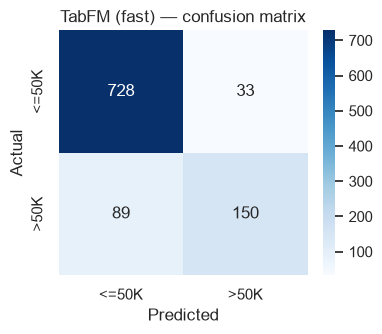

              precision    recall  f1-score   support

       <=50K       0.89      0.96      0.92       761
        >50K       0.82      0.63      0.71       239

    accuracy                           0.88      1000
   macro avg       0.86      0.79      0.82      1000
weighted avg       0.87      0.88      0.87      1000



In [16]:
cm = confusion_matrix(y_eval_bin, pred_fast_eval)
plt.figure(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TabFM (fast) — confusion matrix")
plt.tight_layout()
plt.show()

print(classification_report(y_eval_bin, pred_fast_eval, target_names=["<=50K", ">50K"]))


## 11. Probability Calibration

Accuracy tells you how often a model is *right*; calibration tells you whether its confidence is
*trustworthy* — if a model says "70% probability of `>50K`," does that outcome actually happen
about 70% of the time among all the cases it said that? We already have every probability we need
cached from Sections 8–10, so this section makes **zero new calls to any model.**


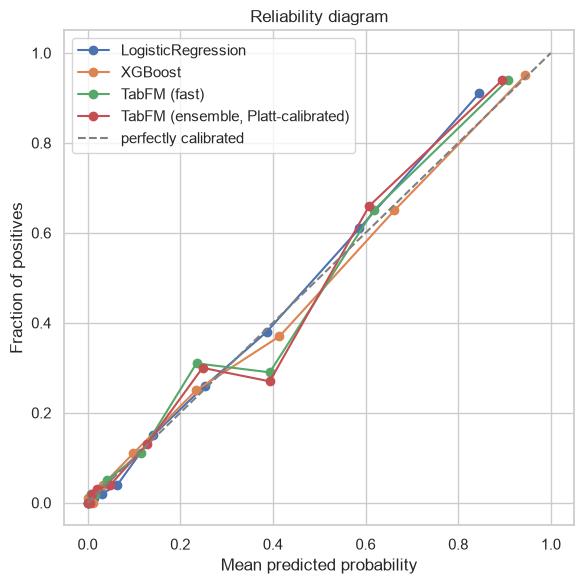

Brier scores (lower is better):


,brier
LogisticRegression,0.0963
XGBoost,0.0833
TabFM (fast),0.0897
TabFM (ensemble),0.0903


In [17]:
plt.figure(figsize=(6, 6))
for name, proba in [
    ("LogisticRegression", logreg_proba),
    ("XGBoost", xgb_proba),
    ("TabFM (fast)", proba_fast_eval),
    ("TabFM (ensemble, Platt-calibrated)", proba_ens_eval),
]:
    frac_pos, mean_pred = calibration_curve(y_eval_bin, proba, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Reliability diagram")
plt.legend()
plt.tight_layout()
plt.show()

print("Brier scores (lower is better):")
display(pd.DataFrame(results).T[["brier"]].round(4))


## 12. Interpreting a Black-Box Foundation Model

`XGBoost` ships `.feature_importances_` for free — it learned per-dataset splits, so it knows which
features it used. TabFM has no such thing: it never trains on your dataset, so there is no
per-dataset weight to inspect. The standard workaround for any black-box model is **permutation
importance**: shuffle one feature's values (breaking its relationship with the target) and measure
how much a metric degrades. A feature that matters a lot will hurt performance badly when
scrambled; an irrelevant one won't.

Because this requires several fresh `predict_proba` calls (one per feature, plus a baseline), we
use a **much smaller, dedicated context** (300 rows) purely for this section — otherwise this
analysis alone would cost as much as the entire rest of the notebook.


Micro-eval (300-row context / 100-row eval) baseline AUC: 0.895  (4.7s total)


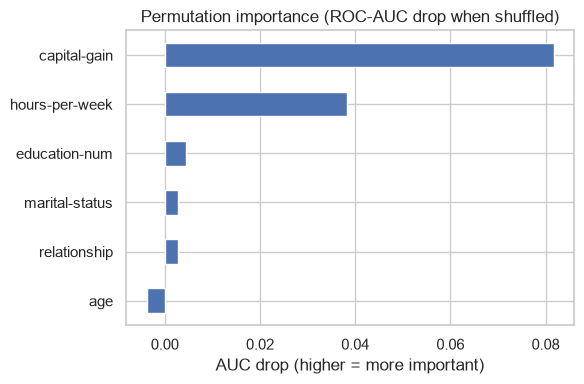

In [18]:
PERM_FEATURES = ["age", "education-num", "hours-per-week", "capital-gain", "relationship", "marital-status"]

X_perm_context, y_perm_context = stratified_subsample(X_train_pool, y_train_pool, 300, seed=7)
X_perm_eval, y_perm_eval = stratified_subsample(X_test_pool, y_test_pool, 100, seed=7)
y_perm_eval_bin = (y_perm_eval == ">50K").astype(int).to_numpy()

clf_perm = TabFMClassifier(model=tabfm_model, n_estimators=2, batch_size=1, random_state=42)

t0 = time.time()
clf_perm.fit(X_perm_context, y_perm_context.to_numpy())


def auc_for(X_):
    idx = list(clf_perm.classes_).index(">50K")
    p = clf_perm.predict_proba(X_)[:, idx]
    return roc_auc_score(y_perm_eval_bin, p)


base_auc = auc_for(X_perm_eval)
importances = {}
rng = np.random.RandomState(0)
for feat in PERM_FEATURES:
    X_shuffled = X_perm_eval.copy()
    X_shuffled[feat] = rng.permutation(X_shuffled[feat].to_numpy())
    importances[feat] = base_auc - auc_for(X_shuffled)

print(f"Micro-eval (300-row context / 100-row eval) baseline AUC: {base_auc:.3f}  ({time.time() - t0:.1f}s total)")

pd.Series(importances).sort_values().plot(
    kind="barh", figsize=(6, 4), title="Permutation importance (ROC-AUC drop when shuffled)", color="#4C72B0"
)
plt.xlabel("AUC drop (higher = more important)")
plt.tight_layout()
plt.show()


## 13. Subgroup Check: Does Performance Hold Up Across `sex` and `race`?

TabFM's model card explicitly flags that performance on minority groups isn't fully characterized,
since the model never sees any real-world data at all during training. Let's check it on our own
evaluation set — using the **already-computed** `proba_fast_eval` / `pred_fast_eval` from Section
9, so again, no new model calls.


In [19]:
subgroup_df = X_eval[["sex", "race"]].copy()
subgroup_df["y_true"] = y_eval_bin.values
subgroup_df["pred"] = pred_fast_eval
subgroup_df["proba"] = proba_fast_eval

for col in ["sex", "race"]:
    print(f"\nBy {col}:")
    rows = []
    for val, d in subgroup_df.groupby(col):
        rows.append({
            col: val,
            "n": len(d),
            "base_rate(>50K)": round(d["y_true"].mean(), 3),
            "accuracy": round(accuracy_score(d["y_true"], d["pred"]), 3),
            "roc_auc": round(roc_auc_score(d["y_true"], d["proba"]), 3) if d["y_true"].nunique() > 1 else float("nan"),
        })
    display(pd.DataFrame(rows))



By sex:


,sex,n,base_rate(>50K),accuracy,roc_auc
0,Female,345,0.113,0.951,0.974
1,Male,655,0.305,0.840,0.894



By race:


,race,n,base_rate(>50K),accuracy,roc_auc
0,Amer-Indian-Eskimo,11,0.091,0.909,0.600
1,Asian-Pac-Islander,26,0.346,0.769,0.915
2,Black,99,0.131,0.939,0.972
3,Other,13,0.154,1.000,1.000
4,White,851,0.251,0.872,0.920


Small subgroups (particularly by `race`) will have wide uncertainty on only ~1,000 eval rows — read
the `n` column before drawing conclusions from any single cell. This is exactly the kind of
breakdown you'd want to run at full evaluation-set scale before trusting a model like this in any
higher-stakes setting.


## 14. Predictions for the New Applicants

Back to the three synthetic applicants from Section 9 — their probabilities came along for free in
the same forward pass as our evaluation set. Let's read them.


In [20]:
for i, row in new_applicants.iterrows():
    print(f"Applicant {i + 1}: age={row['age']}, education={row['education']}, "
          f"occupation={row['occupation']}, hours/week={row['hours-per-week']}, "
          f"capital-gain={row['capital-gain']}")
    print(f"  P(income > $50K) -- TabFM (fast): {proba_fast_new[i]:.3f}  |  TabFM (ensemble): {proba_ens_new[i]:.3f}")
    print()


Applicant 1: age=29, education=Bachelors, occupation=Tech-support, hours/week=40, capital-gain=0
  P(income > $50K) -- TabFM (fast): 0.033  |  TabFM (ensemble): 0.042

Applicant 2: age=52, education=Masters, occupation=Exec-managerial, hours/week=55, capital-gain=15000
  P(income > $50K) -- TabFM (fast): 0.999  |  TabFM (ensemble): 0.998

Applicant 3: age=22, education=HS-grad, occupation=Handlers-cleaners, hours/week=25, capital-gain=0
  P(income > $50K) -- TabFM (fast): 0.001  |  TabFM (ensemble): 0.001



## 15. Practical Notes, Gotchas, and When to Reach for TabFM

**What we hit building this notebook (all real, all current as of this writing):**

- The PyPI package `tabfm==1.0.0` ships a loader that hardcodes `pytorch_model.bin`, but the
  Hugging Face repo only contains `model.safetensors` — install from GitHub `main` instead.
- `huggingface_hub`'s safetensors path imports `safetensors` lazily and fails with a bare
  `NameError` if it isn't installed separately — install it explicitly.
- On CPU, the model's default `bfloat16` compute dtype measured **~4× slower** than `float32` in
  our own timing (191s vs. 48s for an identical tiny workload) — request `float32` explicitly on
  CPU.
- `max_num_rows` and `enable_nnls=True` (which `.ensemble()` sets automatically) cannot be used
  together — pre-subsample your context yourself instead of relying on `max_num_rows`.
- The GPU is easy to starve accidentally if it's shared with other processes (other notebooks, a
  local LLM server, etc.) — always check free memory before grabbing it.

**Documented hard limits (from the model card, not from us):**

- **Classification is capped at 10 output classes.** This is architectural, not configurable.
- **Memory scales with context rows** — there's no free way around the cost/context tradeoff
  discussed in Section 7.
- Optimized for tables up to ~500 features; behavior beyond that "may degrade."
- **The pretrained weights are non-commercial-licensed.** Plan accordingly before building a
  product on top of them.
- Trained entirely on synthetic data — there is no guarantee it has seen anything resembling your
  specific real-world domain.

**What we actually measured, on this exact problem, on CPU:**


In [21]:
timing = pd.DataFrame({
    "wall_clock_s": {
        "TabFM (fast, n_est=8)": fast_time,
        "TabFM (ensemble, n_est=12)": ens_time,
    }
})
display(timing.round(1))
display(pd.DataFrame(results).T.round(4))


,wall_clock_s
"TabFM (fast, n_est=8)",21.2
"TabFM (ensemble, n_est=12)",146.5


,accuracy,roc_auc,f1,log_loss,brier
LogisticRegression,0.866,0.9154,0.6840,0.3038,0.0963
XGBoost,0.880,0.9355,0.7333,0.2633,0.0833
TabFM (fast),0.878,0.9247,0.7109,0.2850,0.0897
TabFM (ensemble),0.878,0.9231,0.7081,0.2872,0.0903


**When each approach makes sense:**

- **Reach for TabFM** when you want a strong baseline *fast*, with zero hyperparameter tuning, on a
  small-to-medium dataset, and you're not latency- or throughput-constrained. It genuinely removes
  the "which model, which hyperparameters" decision for a first pass.
- **Reach for a tuned GBM (XGBoost/LightGBM/CatBoost)** when you have a large dataset, need
  low-latency or high-throughput inference, need to serve predictions on CPU-only infrastructure at
  scale, or need a model you're free to license commercially without restriction.
- **Don't take any zero-shot "beats XGBoost" headline number at face value** — always build your
  own comparison on your own held-out data, the way we did in Sections 8–10, rather than trusting a
  vendor's self-reported benchmark.


## 16. Summary and References

We built a full, real pipeline around Google's TabFM: downloaded a production-grade dataset live,
established honest classical baselines, ran zero-shot inference with two different TabFM presets,
measured calibration, interpreted a black-box in-context model via permutation importance, audited
subgroup performance, and made new predictions — all while surfacing the real engineering gotchas
(a broken PyPI release, a slow default dtype, an incompatible parameter combination) that a
"just call `.fit()` and `.predict()`" tutorial would have hidden.

**References:**

- [Google Research blog: "Introducing TabFM"](https://research.google/blog/introducing-tabfm-a-zero-shot-foundation-model-for-tabular-data/)
- [github.com/google-research/tabfm](https://github.com/google-research/tabfm) — source code (Apache-2.0)
- [huggingface.co/google/tabfm-1.0.0-pytorch](https://huggingface.co/google/tabfm-1.0.0-pytorch) — model card, weights license
- [TabArena benchmark](https://arxiv.org/pdf/2506.16791) — the evaluation suite Google used
- [TabPFN-2.5 technical report](https://arxiv.org/abs/2511.08667) — the architectural lineage TabFM builds on
- [UCI Adult / Census Income dataset on OpenML](https://www.openml.org/d/1590)
